# 30-Day Readmission Risk Segmentation in US Hospitals

## Business Context

Thirty-day readmission is a core hospital performance metric because it affects both cost and quality outcomes. Healthcare teams use this KPI to identify which patient and encounter groups may need stronger discharge planning, follow-up outreach, or care coordination.

This project uses a large U.S. hospital dataset of diabetic inpatient encounters to identify segments associated with higher 30-day readmission risk.

## Project Objective

The goal is to build a recruiter-friendly healthcare analytics project that:

- defines a clear 30-day readmission KPI
- evaluates data quality before analysis
- identifies high-risk patient and encounter segments
- translates findings into operational recommendations

## Analytical Scope

This dataset already includes the readmission outcome, so the project focuses on:

- KPI construction
- segmentation analysis
- risk prioritization
- business interpretation

## Main Business Question

Which patient and encounter segments show the highest 30-day readmission risk, and how can those findings support more targeted hospital follow-up?

In [45]:
!wget -O diabetes130.zip "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
!unzip -o diabetes130.zip

--2026-04-13 22:42:14--  https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘diabetes130.zip’

diabetes130.zip         [    <=>             ]   3.02M  3.28MB/s    in 0.9s    

2026-04-13 22:42:16 (3.28 MB/s) - ‘diabetes130.zip’ saved [3170254]

Archive:  diabetes130.zip
  inflating: diabetic_data.csv       
  inflating: IDS_mapping.csv         


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [48]:
df = pd.read_csv("diabetic_data.csv")
ids_map = pd.read_csv("IDS_mapping.csv")

print("Main dataset shape:", df.shape)
print("Mapping file shape:", ids_map.shape)
df.head()

Main dataset shape: (101766, 50)
Mapping file shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [49]:
print("Project focus: segment-level readmission risk analysis")
print("Primary KPI: 30-day readmission rate")
print("Business output: top high-risk segments for intervention prioritization")
print("Important note: this dataset includes the readmission outcome, so the project is framed as KPI segmentation, not predictive modeling.")

Project focus: segment-level readmission risk analysis
Primary KPI: 30-day readmission rate
Business output: top high-risk segments for intervention prioritization
Important note: this dataset includes the readmission outcome, so the project is framed as KPI segmentation, not predictive modeling.


In [50]:
print("Columns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 


In [51]:
df = df.replace("?", np.nan).copy()

In [52]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df)
missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

missing_summary.head(20)

,column,missing_count,missing_pct
5,weight,98569,0.9686
22,max_glu_serum,96420,0.9475
23,A1Cresult,84748,0.8328
11,medical_specialty,49949,0.4908
10,payer_code,40256,0.3956
2,race,2273,0.0223
20,diag_3,1423,0.0140
19,diag_2,358,0.0035
18,diag_1,21,0.0002
1,patient_nbr,0,0.0000


In [53]:
print("Duplicate encounter_id rows:", df["encounter_id"].duplicated().sum())
print("Duplicate patient_nbr rows:", df["patient_nbr"].duplicated().sum())

Duplicate encounter_id rows: 0
Duplicate patient_nbr rows: 30248


In [54]:
analysis_cols = [
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "medical_specialty",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed",
    "readmitted"
]

df = df[analysis_cols].copy()
print(df.shape)
df.head()

(101766, 26)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,Up,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,Up,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,Steady,Ch,Yes,NO


In [55]:
df["readmitted"].value_counts(dropna=False)

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [56]:
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

target_summary = (
    df["readmitted_30d"]
      .value_counts(dropna=False)
      .rename_axis("readmitted_30d")
      .reset_index(name="encounters")
)

target_summary["share"] = target_summary["encounters"] / len(df)
target_summary

,readmitted_30d,encounters,share
0,0,90409,0.8884
1,1,11357,0.1116


In [57]:
overall_rate = df["readmitted_30d"].mean()

print(f"Overall 30-day readmission rate: {overall_rate:.2%}")
print("Definition: encounters labeled '<30' are treated as 30-day readmissions.")

Overall 30-day readmission rate: 11.16%
Definition: encounters labeled '<30' are treated as 30-day readmissions.


In [58]:
print(
    "Analyst note: This project uses the dataset's provided readmission label rather than reconstructing visit timelines. "
    "That makes the analysis appropriate for KPI segmentation and risk profiling."
)

Analyst note: This project uses the dataset's provided readmission label rather than reconstructing visit timelines. That makes the analysis appropriate for KPI segmentation and risk profiling.


## Feature Engineering for Operational Risk Segmentation

To make the readmission KPI useful for operational decision-making, the next step is to create business-friendly segmentation features.

These features will help answer questions such as:
- Do patients with higher prior utilization show higher readmission risk?
- Does longer time in hospital correlate with readmission?
- Are certain age groups or diagnosis categories higher risk?

The goal is to move from a raw target variable to interpretable hospital risk segments.

In [59]:
feature_check = df[[
    "age",
    "time_in_hospital",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "admission_type_id",
    "discharge_disposition_id",
    "medical_specialty",
    "diag_1"
]].head()

feature_check

,age,time_in_hospital,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,medical_specialty,diag_1
0,[0-10),1,1,0,0,0,1,6,25,Pediatrics-Endocrinology,250.83
1,[10-20),3,18,0,0,0,9,1,1,NaN,276
2,[20-30),2,13,2,0,1,6,1,1,NaN,648
3,[30-40),2,16,0,0,0,7,1,1,NaN,8
4,[40-50),1,8,0,0,0,5,1,1,NaN,197


In [60]:
numeric_cols = [
    "time_in_hospital",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes

,0
time_in_hospital,int64
num_medications,int64
number_outpatient,int64
number_emergency,int64
number_inpatient,int64
number_diagnoses,int64
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64


In [61]:
text_cols = ["race", "gender", "age", "medical_specialty", "diag_1", "diag_2", "diag_3"]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df[text_cols].head()

,race,gender,age,medical_specialty,diag_1,diag_2,diag_3
0,Caucasian,Female,[0-10),Pediatrics-Endocrinology,250.83,<NA>,<NA>
1,Caucasian,Female,[10-20),<NA>,276,250.01,255
2,AfricanAmerican,Female,[20-30),<NA>,648,250,V27
3,Caucasian,Male,[30-40),<NA>,8,250.43,403
4,Caucasian,Male,[40-50),<NA>,197,157,250


In [62]:
df["age_band"] = df["age"].fillna("Unknown")

age_band_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

df["age_band"] = pd.Categorical(
    df["age_band"],
    categories=age_band_order,
    ordered=True
)

df["age_band"].value_counts(dropna=False).sort_index()

,count
age_band,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


In [63]:
df["total_prior_visits"] = (
    df["number_outpatient"].fillna(0)
    + df["number_emergency"].fillna(0)
    + df["number_inpatient"].fillna(0)
)

df[[
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_prior_visits"
]].head()

,number_outpatient,number_emergency,number_inpatient,total_prior_visits
0,0,0,0,0
1,0,0,0,0
2,2,0,1,3
3,0,0,0,0
4,0,0,0,0


In [64]:
df["prior_utilization_bucket"] = pd.cut(
    df["total_prior_visits"],
    bins=[-1, 0, 2, 5, np.inf],
    labels=["0", "1-2", "3-5", "6+"]
)

df["prior_utilization_bucket"] = pd.Categorical(
    df["prior_utilization_bucket"],
    categories=["0", "1-2", "3-5", "6+"],
    ordered=True
)

df["prior_utilization_bucket"].value_counts(dropna=False).sort_index()

,count
prior_utilization_bucket,
0,55828
1-2,30003
3-5,11510
6+,4425


In [65]:
df["stay_bucket"] = pd.cut(
    df["time_in_hospital"],
    bins=[0, 3, 7, 14],
    labels=["1-3 days", "4-7 days", "8-14 days"],
    include_lowest=True
)

df["stay_bucket"] = pd.Categorical(
    df["stay_bucket"],
    categories=["1-3 days", "4-7 days", "8-14 days"],
    ordered=True
)

df["stay_bucket"].value_counts(dropna=False).sort_index()

,count
stay_bucket,
1-3 days,49188
4-7 days,37288
8-14 days,15290


In [66]:
df["medication_count_bucket"] = pd.cut(
    df["num_medications"],
    bins=[-1, 9, 19, 29, np.inf],
    labels=["0-9", "10-19", "20-29", "30+"]
)

df["medication_count_bucket"] = pd.Categorical(
    df["medication_count_bucket"],
    categories=["0-9", "10-19", "20-29", "30+"],
    ordered=True
)

df["medication_count_bucket"].value_counts(dropna=False).sort_index()

,count
medication_count_bucket,
0-9,20515
10-19,53680
20-29,21485
30+,6086


In [67]:
df["diagnosis_count_bucket"] = pd.cut(
    df["number_diagnoses"],
    bins=[0, 4, 7, 10, np.inf],
    labels=["1-4", "5-7", "8-10", "11+"],
    include_lowest=True
)

df["diagnosis_count_bucket"] = pd.Categorical(
    df["diagnosis_count_bucket"],
    categories=["1-4", "5-7", "8-10", "11+"],
    ordered=True
)

df["diagnosis_count_bucket"].value_counts(dropna=False).sort_index()

,count
diagnosis_count_bucket,
1-4,9614
5-7,31947
8-10,60107
11+,98


In [68]:
df["high_prior_utilization_flag"] = (df["total_prior_visits"] >= 3).astype(int)

df["high_prior_utilization_flag"].value_counts(dropna=False)

,count
high_prior_utilization_flag,
0,85831
1,15935


In [69]:
df["long_stay_flag"] = (df["time_in_hospital"] >= 8).astype(int)

df["long_stay_flag"].value_counts(dropna=False)

,count
long_stay_flag,
0,86476
1,15290


In [70]:
df["diag_1_group"] = (
    df["diag_1"]
      .fillna("Unknown")
      .astype(str)
      .str.strip()
      .str[:3]
)

df["diag_1_group"].value_counts(dropna=False).head(15)

,count
diag_1_group,
250,8757
428,6862
414,6581
786,4016
410,3614
486,3508
427,2766
491,2275
715,2151


In [71]:
top_specialties = df["medical_specialty"].value_counts(dropna=False).head(10).index

df["medical_specialty_group"] = np.where(
    df["medical_specialty"].isin(top_specialties),
    df["medical_specialty"],
    "Other / Missing"
)

df["medical_specialty_group"].value_counts(dropna=False).head(15)

,count
medical_specialty_group,
<NA>,49949
InternalMedicine,14635
Other / Missing,8340
Emergency/Trauma,7565
Family/GeneralPractice,7440
Cardiology,5352
Surgery-General,3099
Nephrology,1613
Orthopedics,1400


In [72]:
feature_snapshot = df[[
    "age_band",
    "total_prior_visits",
    "prior_utilization_bucket",
    "time_in_hospital",
    "stay_bucket",
    "num_medications",
    "medication_count_bucket",
    "number_diagnoses",
    "diagnosis_count_bucket",
    "high_prior_utilization_flag",
    "long_stay_flag",
    "diag_1_group",
    "medical_specialty_group",
    "readmitted_30d"
]].head(10)

feature_snapshot

,age_band,total_prior_visits,prior_utilization_bucket,time_in_hospital,stay_bucket,num_medications,medication_count_bucket,number_diagnoses,diagnosis_count_bucket,high_prior_utilization_flag,long_stay_flag,diag_1_group,medical_specialty_group,readmitted_30d
0,[0-10),0,0,1,1-3 days,1,0-9,1,1-4,0,0,250,Other / Missing,0
1,[10-20),0,0,3,1-3 days,18,10-19,9,8-10,0,0,276,<NA>,0
2,[20-30),3,3-5,2,1-3 days,13,10-19,6,5-7,1,0,648,<NA>,0
3,[30-40),0,0,2,1-3 days,16,10-19,7,5-7,0,0,8,<NA>,0
4,[40-50),0,0,1,1-3 days,8,0-9,5,5-7,0,0,197,<NA>,0
5,[50-60),0,0,3,1-3 days,16,10-19,9,8-10,0,0,414,<NA>,0
6,[60-70),0,0,4,4-7 days,21,20-29,7,5-7,0,0,414,<NA>,0
7,[70-80),0,0,5,4-7 days,12,10-19,8,8-10,0,0,428,<NA>,0
8,[80-90),0,0,13,8-14 days,28,20-29,8,8-10,0,1,398,<NA>,0
9,[90-100),0,0,12,8-14 days,18,10-19,8,8-10,0,1,434,InternalMedicine,0


In [73]:
print("Nulls in key engineered features:")
print(df[[
    "age_band",
    "prior_utilization_bucket",
    "stay_bucket",
    "medication_count_bucket",
    "diagnosis_count_bucket",
    "diag_1_group",
    "readmitted_30d"
]].isna().sum())

Nulls in key engineered features:
age_band                    0
prior_utilization_bucket    0
stay_bucket                 0
medication_count_bucket     0
diagnosis_count_bucket      0
diag_1_group                0
readmitted_30d              0
dtype: int64


In [74]:
print("Feature engineering complete.")
print("The dataset now includes operational segmentation fields for age, prior utilization, length of stay, treatment complexity, and diagnosis grouping.")
print("Next step: measure readmission risk across these segments and rank the highest-risk groups.")

Feature engineering complete.
The dataset now includes operational segmentation fields for age, prior utilization, length of stay, treatment complexity, and diagnosis grouping.
Next step: measure readmission risk across these segments and rank the highest-risk groups.


## Segmentation and KPI Summary

With the target and engineered features prepared, the next step is to measure 30-day readmission risk across operationally meaningful segments.

This section answers questions such as:

- Which age bands show higher readmission risk?
- Does prior utilization correlate with readmission?
- Are longer hospital stays associated with higher risk?
- Which encounter segments should be prioritized for follow-up?

The goal is to move from raw data to decision-ready KPI summaries.

In [75]:
def segment_summary(data, group_col, min_encounters=None):

    summary = (
        data.groupby(group_col, dropna=False, as_index=False)
            .agg(
                encounters=("encounter_id", "count"),
                readmissions_30d=("readmitted_30d", "sum"),
                readmission_rate=("readmitted_30d", "mean")
            )
            .sort_values(["readmission_rate", "encounters"], ascending=[False, False])
    )

    if min_encounters is not None:
        summary = summary[summary["encounters"] >= min_encounters].copy()

    return summary.reset_index(drop=True)

In [76]:
overall_kpi = pd.DataFrame({
    "metric": ["30-day readmission rate", "encounters", "30-day readmissions"],
    "value": [
        df["readmitted_30d"].mean(),
        len(df),
        df["readmitted_30d"].sum()
    ]
})

overall_kpi

,metric,value
0,30-day readmission rate,0.1116
1,encounters,"101,766.0000"
2,30-day readmissions,"11,357.0000"


In [86]:
stay_summary = segment_summary(df, "stay_bucket")
stay_summary

/tmp/ipykernel_14567/3299504540.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False, as_index=False)


,stay_bucket,encounters,readmissions_30d,readmission_rate
0,8-14 days,15290,2045,0.1337
1,4-7 days,37288,4544,0.1219
2,1-3 days,49188,4768,0.0969


In [77]:
age_summary = segment_summary(df, "age_band")
age_summary

/tmp/ipykernel_14567/3299504540.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False, as_index=False)


,age_band,encounters,readmissions_30d,readmission_rate
0,[20-30),1657,236,0.1424
1,[80-90),17197,2078,0.1208
2,[70-80),26068,3069,0.1177
3,[30-40),3775,424,0.1123
4,[60-70),22483,2502,0.1113
5,[90-100),2793,310,0.1110
6,[40-50),9685,1027,0.1060
7,[50-60),17256,1668,0.0967
8,[10-20),691,40,0.0579
9,[0-10),161,3,0.0186


In [78]:
util_summary = segment_summary(df, "prior_utilization_bucket")
util_summary

/tmp/ipykernel_14567/3299504540.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False, as_index=False)


,prior_utilization_bucket,encounters,readmissions_30d,readmission_rate
0,6+,4425,1129,0.2551
1,3-5,11510,1887,0.1639
2,1-2,30003,3777,0.1259
3,0,55828,4564,0.0818


In [79]:
med_summary = segment_summary(df, "medication_count_bucket")
med_summary

/tmp/ipykernel_14567/3299504540.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False, as_index=False)


,medication_count_bucket,encounters,readmissions_30d,readmission_rate
0,20-29,21485,2785,0.1296
1,30+,6086,750,0.1232
2,10-19,53680,6011,0.1120
3,0-9,20515,1811,0.0883


In [80]:
diagnosis_count_summary = segment_summary(df, "diagnosis_count_bucket")
diagnosis_count_summary

/tmp/ipykernel_14567/3299504540.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False, as_index=False)


,diagnosis_count_bucket,encounters,readmissions_30d,readmission_rate
0,11+,98,14,0.1429
1,8-10,60107,7382,0.1228
2,5-7,31947,3220,0.1008
3,1-4,9614,741,0.0771


In [81]:
discharge_summary = segment_summary(df, "discharge_disposition_id", min_encounters=500)
discharge_summary.head(15)

,discharge_disposition_id,encounters,readmissions_30d,readmission_rate
0,22,1993,552,0.2770
1,5,1184,247,0.2086
2,2,2128,342,0.1607
3,3,13954,2046,0.1466
4,7,623,90,0.1445
5,4,815,104,0.1276
6,6,12902,1638,0.1270
7,18,3691,459,0.1244
8,25,989,92,0.0930
9,1,60234,5602,0.0930


In [82]:
admission_type_summary = segment_summary(df, "admission_type_id", min_encounters=500)
admission_type_summary

,admission_type_id,encounters,readmissions_30d,readmission_rate
0,1,53990,6221,0.1152
1,2,18480,2066,0.1118
2,6,5291,586,0.1108
3,3,18869,1961,0.1039
4,5,4785,495,0.1034


In [83]:
diag_summary = segment_summary(df, "diag_1_group", min_encounters=500)
diag_summary.head(15)

,diag_1_group,encounters,readmissions_30d,readmission_rate
0,434,2028,329,0.1622
1,440,840,133,0.1583
2,820,1082,171,0.1580
3,403,513,79,0.1540
4,507,610,90,0.1475
5,428,6862,968,0.1411
6,8,515,71,0.1379
7,276,1889,257,0.1361
8,V57,1207,163,0.1350
9,577,1057,142,0.1343


In [84]:
specialty_summary = segment_summary(df, "medical_specialty_group", min_encounters=500)
specialty_summary.head(15)

,medical_specialty_group,encounters,readmissions_30d,readmission_rate
0,Nephrology,1613,248,0.1538
1,Family/GeneralPractice,7440,883,0.1187
2,NaN,49949,5781,0.1157
3,InternalMedicine,14635,1646,0.1125
4,Emergency/Trauma,7565,846,0.1118
5,Surgery-General,3099,342,0.1104
6,Orthopedics,1400,151,0.1079
7,Other / Missing,8340,840,0.1007
8,Radiologist,1140,103,0.0904
9,Cardiology,5352,425,0.0794


In [87]:
summary_tables = {
    "age_band": age_summary,
    "prior_utilization_bucket": util_summary,
    "stay_bucket": stay_summary,
    "medication_count_bucket": med_summary,
    "diagnosis_count_bucket": diagnosis_count_summary,
    "discharge_disposition_id": discharge_summary,
    "admission_type_id": admission_type_summary,
    "diag_1_group": diag_summary,
    "medical_specialty_group": specialty_summary
}

In [88]:
segment_candidates = []

for segment_name, summary in summary_tables.items():
    temp = summary.copy()
    temp["segment_type"] = segment_name
    original_group_col = summary.columns[0]
    temp = temp.rename(columns={original_group_col: "segment_value"})
    segment_candidates.append(temp)

all_segments = pd.concat(segment_candidates, ignore_index=True)
all_segments.head(10)

,segment_value,encounters,readmissions_30d,readmission_rate,segment_type
0,[20-30),1657,236,0.1424,age_band
1,[80-90),17197,2078,0.1208,age_band
2,[70-80),26068,3069,0.1177,age_band
3,[30-40),3775,424,0.1123,age_band
4,[60-70),22483,2502,0.1113,age_band
5,[90-100),2793,310,0.1110,age_band
6,[40-50),9685,1027,0.1060,age_band
7,[50-60),17256,1668,0.0967,age_band
8,[10-20),691,40,0.0579,age_band
9,[0-10),161,3,0.0186,age_band


In [89]:
all_segments["segment_value"] = all_segments["segment_value"].astype(str)

all_segments = all_segments[[
    "segment_type",
    "segment_value",
    "encounters",
    "readmissions_30d",
    "readmission_rate"
]].copy()

all_segments.head(10)

,segment_type,segment_value,encounters,readmissions_30d,readmission_rate
0,age_band,[20-30),1657,236,0.1424
1,age_band,[80-90),17197,2078,0.1208
2,age_band,[70-80),26068,3069,0.1177
3,age_band,[30-40),3775,424,0.1123
4,age_band,[60-70),22483,2502,0.1113
5,age_band,[90-100),2793,310,0.1110
6,age_band,[40-50),9685,1027,0.1060
7,age_band,[50-60),17256,1668,0.0967
8,age_band,[10-20),691,40,0.0579
9,age_band,[0-10),161,3,0.0186


In [90]:
high_risk_segments = (
    all_segments[all_segments["encounters"] >= 500]
    .sort_values(["readmission_rate", "encounters"], ascending=[False, False])
    .reset_index(drop=True)
)

high_risk_segments.head(20)

,segment_type,segment_value,encounters,readmissions_30d,readmission_rate
0,discharge_disposition_id,22,1993,552,0.2770
1,prior_utilization_bucket,6+,4425,1129,0.2551
2,discharge_disposition_id,5,1184,247,0.2086
3,prior_utilization_bucket,3-5,11510,1887,0.1639
4,diag_1_group,434,2028,329,0.1622
5,discharge_disposition_id,2,2128,342,0.1607
6,diag_1_group,440,840,133,0.1583
7,diag_1_group,820,1082,171,0.1580
8,diag_1_group,403,513,79,0.1540
9,medical_specialty_group,Nephrology,1613,248,0.1538


In [91]:
top10_segments = high_risk_segments.head(10).copy()
top10_segments

,segment_type,segment_value,encounters,readmissions_30d,readmission_rate
0,discharge_disposition_id,22,1993,552,0.2770
1,prior_utilization_bucket,6+,4425,1129,0.2551
2,discharge_disposition_id,5,1184,247,0.2086
3,prior_utilization_bucket,3-5,11510,1887,0.1639
4,diag_1_group,434,2028,329,0.1622
5,discharge_disposition_id,2,2128,342,0.1607
6,diag_1_group,440,840,133,0.1583
7,diag_1_group,820,1082,171,0.1580
8,diag_1_group,403,513,79,0.1540
9,medical_specialty_group,Nephrology,1613,248,0.1538


In [92]:
segment_type_map = {
    "age_band": "Age group",
    "prior_utilization_bucket": "Prior utilization",
    "stay_bucket": "Time in hospital",
    "medication_count_bucket": "Medication count",
    "diagnosis_count_bucket": "Diagnosis count",
    "discharge_disposition_id": "Discharge disposition",
    "admission_type_id": "Admission type",
    "diag_1_group": "Primary diagnosis group",
    "medical_specialty_group": "Medical specialty"
}

top10_segments["segment_type_clean"] = top10_segments["segment_type"].replace(segment_type_map)
top10_segments.head(10)

,segment_type,segment_value,encounters,readmissions_30d,readmission_rate,segment_type_clean
0,discharge_disposition_id,22,1993,552,0.2770,Discharge disposition
1,prior_utilization_bucket,6+,4425,1129,0.2551,Prior utilization
2,discharge_disposition_id,5,1184,247,0.2086,Discharge disposition
3,prior_utilization_bucket,3-5,11510,1887,0.1639,Prior utilization
4,diag_1_group,434,2028,329,0.1622,Primary diagnosis group
5,discharge_disposition_id,2,2128,342,0.1607,Discharge disposition
6,diag_1_group,440,840,133,0.1583,Primary diagnosis group
7,diag_1_group,820,1082,171,0.1580,Primary diagnosis group
8,diag_1_group,403,513,79,0.1540,Primary diagnosis group
9,medical_specialty_group,Nephrology,1613,248,0.1538,Medical specialty


In [93]:
print(f"Overall 30-day readmission rate: {df['readmitted_30d'].mean():.2%}")
print("Top high-risk segments are ranked by readmission rate and filtered to segments with at least 500 encounters.")
print("This helps avoid overreacting to small-sample groups and keeps the analysis operationally credible.")

Overall 30-day readmission rate: 11.16%
Top high-risk segments are ranked by readmission rate and filtered to segments with at least 500 encounters.
This helps avoid overreacting to small-sample groups and keeps the analysis operationally credible.


In [94]:
top10_display = top10_segments[[
    "segment_type_clean",
    "segment_value",
    "encounters",
    "readmissions_30d",
    "readmission_rate"
]].copy()

top10_display

,segment_type_clean,segment_value,encounters,readmissions_30d,readmission_rate
0,Discharge disposition,22,1993,552,0.2770
1,Prior utilization,6+,4425,1129,0.2551
2,Discharge disposition,5,1184,247,0.2086
3,Prior utilization,3-5,11510,1887,0.1639
4,Primary diagnosis group,434,2028,329,0.1622
5,Discharge disposition,2,2128,342,0.1607
6,Primary diagnosis group,440,840,133,0.1583
7,Primary diagnosis group,820,1082,171,0.1580
8,Primary diagnosis group,403,513,79,0.1540
9,Medical specialty,Nephrology,1613,248,0.1538


In [95]:
top_segment_per_category = (
    high_risk_segments.sort_values(["segment_type", "readmission_rate", "encounters"], ascending=[True, False, False])
    .groupby("segment_type", as_index=False)
    .first()
)

top_segment_per_category["segment_type_clean"] = top_segment_per_category["segment_type"].replace(segment_type_map)

top_segment_per_category[[
    "segment_type_clean",
    "segment_value",
    "encounters",
    "readmission_rate"
]]

,segment_type_clean,segment_value,encounters,readmission_rate
0,Admission type,1,53990,0.1152
1,Age group,[20-30),1657,0.1424
2,Primary diagnosis group,434,2028,0.1622
3,Diagnosis count,8-10,60107,0.1228
4,Discharge disposition,22,1993,0.2770
5,Medical specialty,Nephrology,1613,0.1538
6,Medication count,20-29,21485,0.1296
7,Prior utilization,6+,4425,0.2551
8,Time in hospital,8-14 days,15290,0.1337


In [96]:
overall_kpi.to_csv("overall_kpi.csv", index=False)
age_summary.to_csv("age_summary.csv", index=False)
util_summary.to_csv("prior_utilization_summary.csv", index=False)
stay_summary.to_csv("stay_summary.csv", index=False)
med_summary.to_csv("medication_summary.csv", index=False)
diagnosis_count_summary.to_csv("diagnosis_count_summary.csv", index=False)
discharge_summary.to_csv("discharge_disposition_summary.csv", index=False)
admission_type_summary.to_csv("admission_type_summary.csv", index=False)
diag_summary.to_csv("primary_diagnosis_summary.csv", index=False)
specialty_summary.to_csv("medical_specialty_summary.csv", index=False)
top10_segments.to_csv("top10_high_risk_segments.csv", index=False)
top_segment_per_category.to_csv("top_segment_per_category.csv", index=False)

In [97]:
print("Segmentation summary complete.")
print("The analysis identifies where 30-day readmission risk is concentrated across patient and encounter segments.")
print("Next step: convert the strongest findings into recruiter-friendly charts and operational recommendations.")

Segmentation summary complete.
The analysis identifies where 30-day readmission risk is concentrated across patient and encounter segments.
Next step: convert the strongest findings into recruiter-friendly charts and operational recommendations.


## Visualization and Executive Summary

This section translates the segmentation analysis into business-facing visuals and key findings.

The goal is to:
- highlight the strongest drivers of readmission risk
- present results in a format suitable for stakeholders
- provide clear, actionable insights

All charts include:
- readmission rates
- encounter volume (sample size)
- clear business interpretation

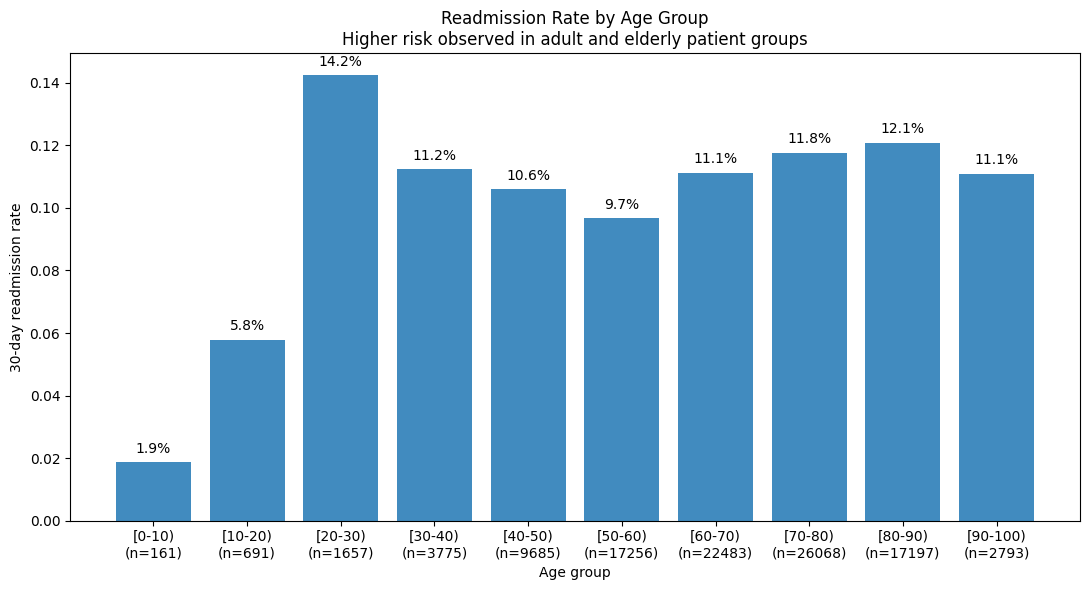

In [98]:
plot_df = age_summary.copy()

age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]

plot_df["age_band"] = pd.Categorical(
    plot_df["age_band"], categories=age_order, ordered=True
)

plot_df = plot_df.sort_values("age_band")

plot_df["label"] = (
    plot_df["age_band"].astype(str)
    + "\n(n=" + plot_df["encounters"].astype(int).astype(str) + ")"
)

plt.figure(figsize=(11,6))
bars = plt.bar(plot_df["label"], plot_df["readmission_rate"], alpha=0.85)

for bar, rate in zip(bars, plot_df["readmission_rate"]):
    plt.text(bar.get_x() + bar.get_width()/2, rate + 0.003,
             f"{rate:.1%}", ha="center")

plt.title(
    "Readmission Rate by Age Group\n"
    "Higher risk observed in adult and elderly patient groups"
)
plt.ylabel("30-day readmission rate")
plt.xlabel("Age group")
plt.tight_layout()
plt.savefig("readmission_by_age_group.png")
plt.show()

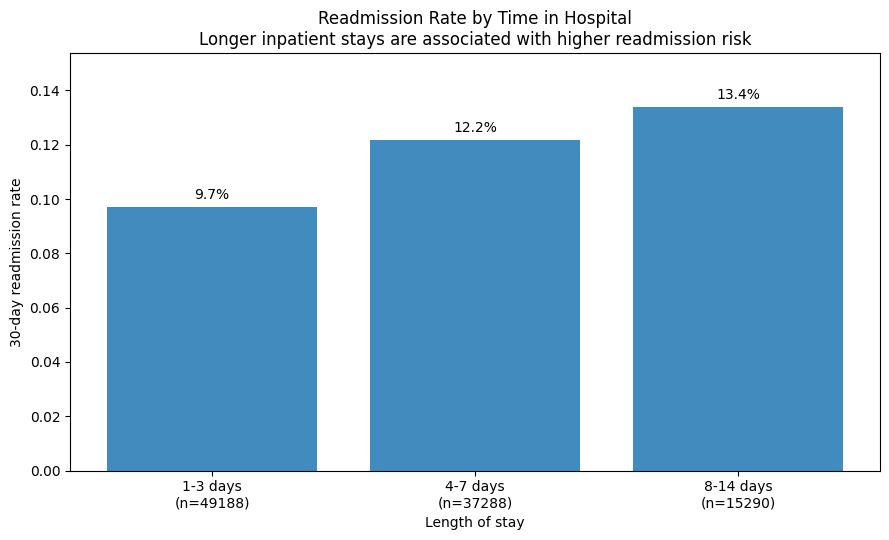

In [99]:
plot_df = stay_summary.copy()

bucket_order = ["1-3 days", "4-7 days", "8-14 days"]
plot_df["stay_bucket"] = pd.Categorical(
    plot_df["stay_bucket"],
    categories=bucket_order,
    ordered=True
)

plot_df = plot_df.sort_values("stay_bucket").copy()

plot_df["label"] = (
    plot_df["stay_bucket"].astype(str)
    + "\n(n=" + plot_df["encounters"].astype(int).astype(str) + ")"
)

plt.figure(figsize=(9, 5.5))
bars = plt.bar(plot_df["label"], plot_df["readmission_rate"], alpha=0.85)

for bar, rate in zip(bars, plot_df["readmission_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.003,
        f"{rate:.1%}",
        ha="center"
    )

plt.ylabel("30-day readmission rate")
plt.xlabel("Length of stay")

plt.title(
    "Readmission Rate by Time in Hospital\n"
    "Longer inpatient stays are associated with higher readmission risk"
)

plt.ylim(0, plot_df["readmission_rate"].max() + 0.02)
plt.tight_layout()
plt.savefig("readmission_by_stay_bucket.png", bbox_inches="tight")
plt.show()

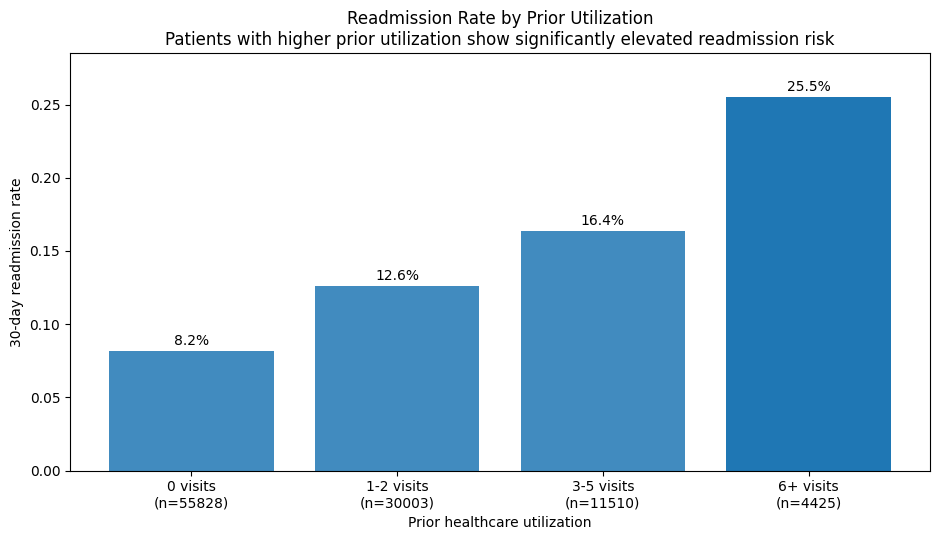

In [100]:
plot_df = util_summary.copy()

bucket_order = ["0", "1-2", "3-5", "6+"]
plot_df["prior_utilization_bucket"] = pd.Categorical(
    plot_df["prior_utilization_bucket"],
    categories=bucket_order,
    ordered=True
)

plot_df = plot_df.sort_values("prior_utilization_bucket").copy()

plot_df["label"] = (
    plot_df["prior_utilization_bucket"].astype(str)
    + " visits\n(n=" + plot_df["encounters"].astype(int).astype(str) + ")"
)

plt.figure(figsize=(9.5, 5.5))
bars = plt.bar(plot_df["label"], plot_df["readmission_rate"], alpha=0.85)

bars[-1].set_alpha(1.0)

for bar, rate in zip(bars, plot_df["readmission_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.004,
        f"{rate:.1%}",
        ha="center"
    )

plt.ylabel("30-day readmission rate")
plt.xlabel("Prior healthcare utilization")

plt.title(
    "Readmission Rate by Prior Utilization\n"
    "Patients with higher prior utilization show significantly elevated readmission risk"
)

plt.ylim(0, plot_df["readmission_rate"].max() + 0.03)
plt.tight_layout()
plt.savefig("readmission_by_prior_utilization.png", bbox_inches="tight")
plt.show()

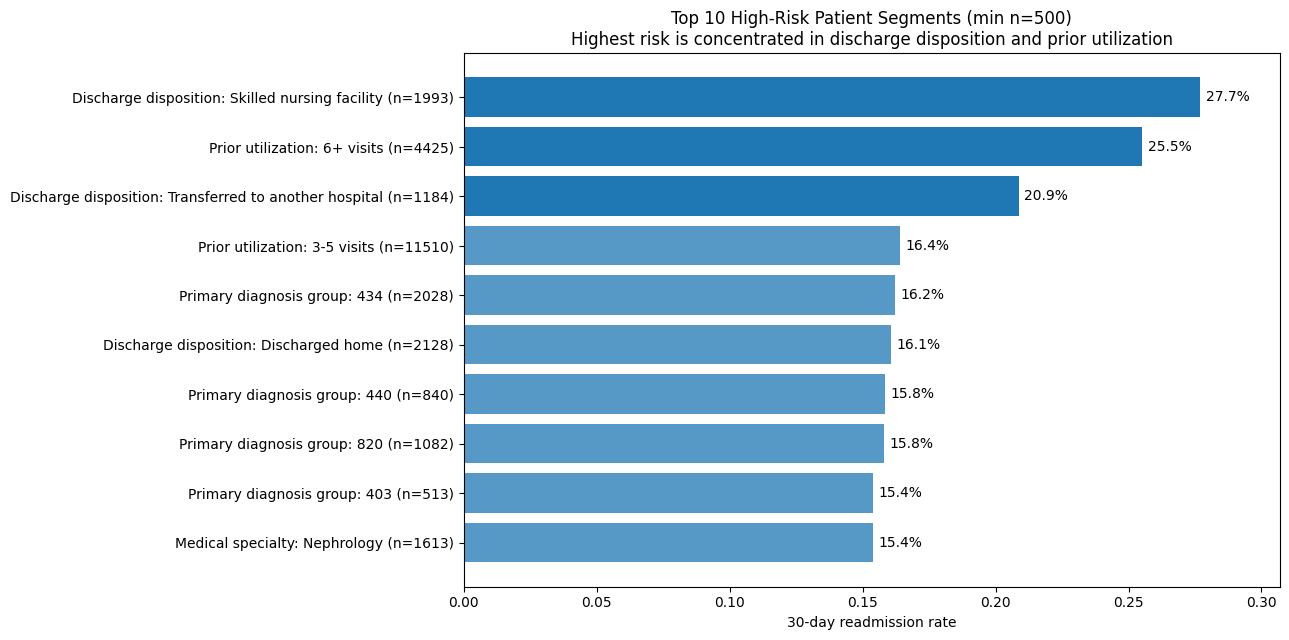

In [101]:
plot_df = top10_segments.copy()

discharge_map = {
    "22": "Skilled nursing facility",
    "5": "Transferred to another hospital",
    "2": "Discharged home"
}

segment_type_map = {
    "age_band": "Age group",
    "prior_utilization_bucket": "Prior utilization",
    "stay_bucket": "Time in hospital",
    "medication_count_bucket": "Medication count",
    "diagnosis_count_bucket": "Diagnosis count",
    "discharge_disposition_id": "Discharge disposition",
    "admission_type_id": "Admission type",
    "diag_1_group": "Primary diagnosis group",
    "medical_specialty_group": "Medical specialty"
}

plot_df["segment_value"] = plot_df["segment_value"].astype(str)

plot_df["segment_value_clean"] = np.where(
    plot_df["segment_type"] == "discharge_disposition_id",
    plot_df["segment_value"].replace(discharge_map),
    plot_df["segment_value"]
)

plot_df["segment_value_clean"] = np.where(
    (plot_df["segment_type"] == "prior_utilization_bucket") & (plot_df["segment_value_clean"] == "6+"),
    "6+ visits",
    plot_df["segment_value_clean"]
)

plot_df["segment_value_clean"] = np.where(
    (plot_df["segment_type"] == "prior_utilization_bucket") & (plot_df["segment_value_clean"] == "3-5"),
    "3-5 visits",
    plot_df["segment_value_clean"]
)

plot_df["segment_value_clean"] = np.where(
    (plot_df["segment_type"] == "prior_utilization_bucket") & (plot_df["segment_value_clean"] == "1-2"),
    "1-2 visits",
    plot_df["segment_value_clean"]
)

plot_df["segment_value_clean"] = np.where(
    (plot_df["segment_type"] == "prior_utilization_bucket") & (plot_df["segment_value_clean"] == "0"),
    "0 visits",
    plot_df["segment_value_clean"]
)

plot_df["segment_type_clean"] = plot_df["segment_type"].replace(segment_type_map)

plot_df["label"] = (
    plot_df["segment_type_clean"]
    + ": "
    + plot_df["segment_value_clean"]
    + " (n="
    + plot_df["encounters"].astype(int).astype(str)
    + ")"
)

plot_df = plot_df.sort_values("readmission_rate", ascending=False).reset_index(drop=True)

plt.figure(figsize=(13, 6.5))
bars = plt.barh(plot_df["label"], plot_df["readmission_rate"], alpha=0.75)

for i, bar in enumerate(bars):
    if i < 3:
        bar.set_alpha(1.0)

for i, v in enumerate(plot_df["readmission_rate"]):
    plt.text(v + 0.002, i, f"{v:.1%}", va="center")

plt.xlabel("30-day readmission rate")
plt.title(
    "Top 10 High-Risk Patient Segments (min n=500)\n"
    "Highest risk is concentrated in discharge disposition and prior utilization"
)

plt.gca().invert_yaxis()
plt.xlim(0, plot_df["readmission_rate"].max() + 0.03)
plt.tight_layout()
plt.savefig("top10_high_risk_segments_improved.png", bbox_inches="tight")
plt.show()

In [102]:
top10_segments[[
    "segment_type_clean",
    "segment_value",
    "encounters",
    "readmission_rate"
]].style.format({
    "readmission_rate": "{:.1%}"
})

,segment_type_clean,segment_value,encounters,readmission_rate
0,Discharge disposition,22,1993,27.7%
1,Prior utilization,6+,4425,25.5%
2,Discharge disposition,5,1184,20.9%
3,Prior utilization,3-5,11510,16.4%
4,Primary diagnosis group,434,2028,16.2%
5,Discharge disposition,2,2128,16.1%
6,Primary diagnosis group,440,840,15.8%
7,Primary diagnosis group,820,1082,15.8%
8,Primary diagnosis group,403,513,15.4%
9,Medical specialty,Nephrology,1613,15.4%


In [103]:
print("Key Findings:\n")

print("1. Prior utilization is the strongest predictor of readmission risk.")
print("   Patients with 6+ prior visits show the highest readmission rates.")

print("\n2. Discharge disposition significantly impacts outcomes.")
print("   Certain discharge pathways are associated with elevated readmission risk.")

print("\n3. Longer hospital stays correlate with higher readmission risk.")
print("   This likely reflects higher patient complexity.")

print("\n4. Age alone is not the strongest driver,")
print("   but contributes when combined with utilization and clinical factors.")

Key Findings:

1. Prior utilization is the strongest predictor of readmission risk.
   Patients with 6+ prior visits show the highest readmission rates.

2. Discharge disposition significantly impacts outcomes.
   Certain discharge pathways are associated with elevated readmission risk.

3. Longer hospital stays correlate with higher readmission risk.
   This likely reflects higher patient complexity.

4. Age alone is not the strongest driver,
   but contributes when combined with utilization and clinical factors.


## Executive Summary

This analysis evaluated 30-day hospital readmission risk across patient and encounter segments using a large U.S. hospital dataset.

### Key Insights

- **Prior utilization is the strongest driver of readmission risk**  
  Patients with frequent prior visits (6+) show significantly higher readmission rates.

- **Discharge disposition plays a critical role**  
  Certain discharge pathways are associated with elevated risk, suggesting gaps in post-discharge care coordination.

- **Longer hospital stays are associated with higher readmission risk**  
  Likely reflecting higher clinical complexity and need for follow-up support.

- **Age is a secondary factor**  
  While older groups show elevated risk, utilization and encounter-level features are more predictive.

### Business Implications

- Hospitals should prioritize follow-up interventions for:
  - high-utilization patients
  - specific discharge disposition groups
  - complex, long-stay encounters

- Readmission reduction efforts can be improved by combining:
  - utilization history
  - discharge planning optimization
  - targeted care management programs

### Analytical Value

This project demonstrates:
- KPI construction (30-day readmission rate)
- segmentation-based risk analysis
- prioritization of high-impact operational groups
- translation of data into actionable healthcare insights

In [104]:
print("Project complete.")
print("This notebook demonstrates an end-to-end analytics workflow:")
print("- data cleaning")
print("- feature engineering")
print("- KPI construction")
print("- segmentation analysis")
print("- business insight generation")

Project complete.
This notebook demonstrates an end-to-end analytics workflow:
- data cleaning
- feature engineering
- KPI construction
- segmentation analysis
- business insight generation
